# Telecom Customer Churn Prediction & Segmentation

**Author:** [Your Name]  
**Dataset:** 99,999 prepaid mobile subscribers | 4 months of behavioral data (June–September)  
**Goal:** Predict which customers will churn next month, and segment the customer base for targeted retention.

---

## 1. Business Problem

In the Indian telecom market, **churn** (when a customer stops using the service) is a major business problem. Acquiring a new customer costs 5–7x more than retaining an existing one.

**Churn Definition Used Here:**  
A customer is considered churned if they had **zero outgoing calls, zero incoming calls, and zero data usage in September** (the "action" month). This is the industry-standard usage-based churn definition.

**The 4-month window:**
- June & July = baseline (normal usage)
- August = early warning signs appear
- September = churn is confirmed (target variable)

> ⚠️ We exclude all September features from model training to avoid data leakage.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)

## 2. Data Understanding

In [3]:
# Load the dataset
df = pd.read_csv('telecom_churn_data.csv')
print(f'Shape: {df.shape}')  # (99999, 226)
print(f'\nColumn groups in dataset:')
print('  - ARPU (avg revenue per user): arpu_6, arpu_7, arpu_8, arpu_9')
print('  - MOU (minutes of usage): total_og_mou_6 ... total_ic_mou_9')
print('  - Recharge: total_rech_amt_6 ... total_rech_num_9')
print('  - Data: vol_2g_mb_6 ... vol_3g_mb_9')
print('  - Roaming, VBC, and other service features')
print('  - aon = age on network (tenure in days)')

Shape: (99999, 226)

Column groups in dataset:
  - ARPU (avg revenue per user): arpu_6, arpu_7, arpu_8, arpu_9
  - MOU (minutes of usage): total_og_mou_6 ... total_ic_mou_9
  - Recharge: total_rech_amt_6 ... total_rech_num_9
  - Data: vol_2g_mb_6 ... vol_3g_mb_9
  - Roaming, VBC, and other service features
  - aon = age on network (tenure in days)


In [4]:
# Derive the churn target variable
# A customer churned if they had ZERO usage in September
for col in ['total_og_mou_9', 'total_ic_mou_9', 'vol_2g_mb_9', 'vol_3g_mb_9']:
    df[col] = df[col].fillna(0)

df['churn'] = (
    (df['total_og_mou_9'] == 0) &
    (df['total_ic_mou_9'] == 0) &
    (df['vol_2g_mb_9']    == 0) &
    (df['vol_3g_mb_9']    == 0)
).astype(int)

n_churn = df['churn'].sum()
print(f'Total customers : {len(df):,}')
print(f'Churners        : {n_churn:,} ({n_churn/len(df)*100:.1f}%)')
print(f'Non-churners    : {len(df)-n_churn:,} ({(1 - n_churn/len(df))*100:.1f}%)')
print('\nClass imbalance ~9:1 — will use class_weight="balanced" in models.')

Total customers : 99,999
Churners        : 10,191 (10.2%)
Non-churners    : 89,808 (89.8%)

Class imbalance ~9:1 — will use class_weight="balanced" in models.


## 3. Exploratory Data Analysis

We look at how key metrics (ARPU, usage, recharges) differ between churners and non-churners. These patterns will guide our feature engineering.

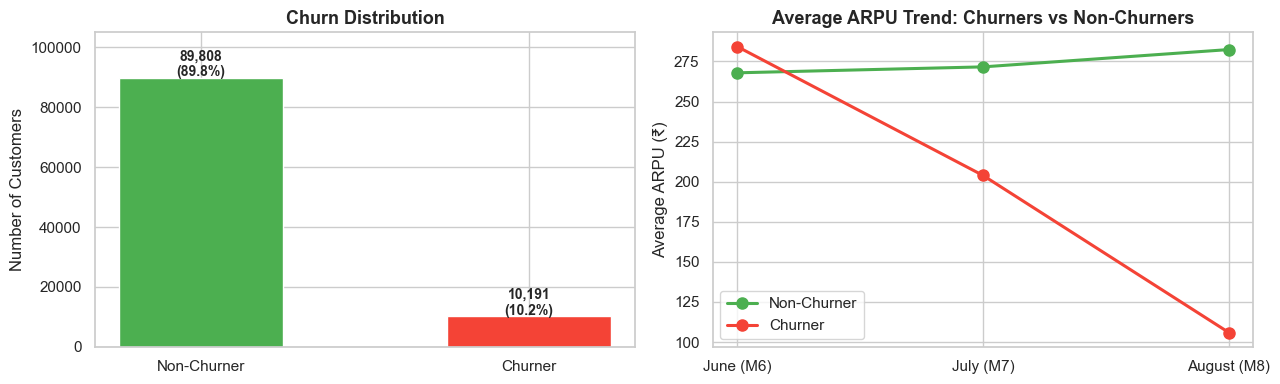

Insight: Non-churners maintain stable ARPU. Churners show a clear drop in August — an early warning signal.


In [5]:
# Plot 1 & 2: Churn distribution + ARPU trend comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Churn distribution ---
counts = df['churn'].value_counts()
axes[0].bar(['Non-Churner', 'Churner'], counts.values,
             color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, 105000)

# --- ARPU trend by churn status ---
months = ['June (M6)', 'July (M7)', 'August (M8)']
for label, color, name in [(0, '#4CAF50', 'Non-Churner'), (1, '#F44336', 'Churner')]:
    means = [df.loc[df['churn'] == label, f'arpu_{m}'].clip(0, 1000).mean()
              for m in [6, 7, 8]]
    axes[1].plot(months, means, marker='o', linewidth=2.2,
                  color=color, label=name, markersize=8)
axes[1].set_title('Average ARPU Trend: Churners vs Non-Churners', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average ARPU (₹)')
axes[1].legend()

plt.tight_layout()
plt.savefig('arpu_trend.png', dpi=110, bbox_inches='tight')
plt.show()
print('Insight: Non-churners maintain stable ARPU. Churners show a clear drop in August — an early warning signal.')

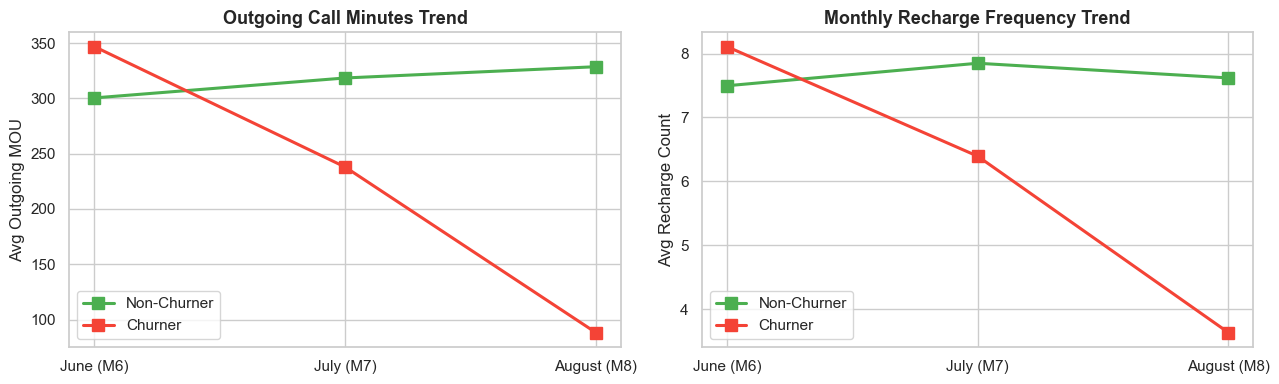

Insight: Both call usage and recharge frequency drop sharply for churners in August, ~30 days before they churn.


In [6]:
# Plot 3 & 4: MOU (call usage) trend + Recharge count trend
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (prefix, ylabel, title) in zip(axes, [
    ('total_og_mou', 'Avg Outgoing MOU', 'Outgoing Call Minutes Trend'),
    ('total_rech_num', 'Avg Recharge Count', 'Monthly Recharge Frequency Trend'),
]):
    for label, color, name in [(0, '#4CAF50', 'Non-Churner'), (1, '#F44336', 'Churner')]:
        means = [df.loc[df['churn'] == label, f'{prefix}_{m}'].mean() for m in [6, 7, 8]]
        ax.plot(months, means, marker='s', linewidth=2.2,
                 color=color, label=name, markersize=8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()
print('Insight: Both call usage and recharge frequency drop sharply for churners in August, ~30 days before they churn.')

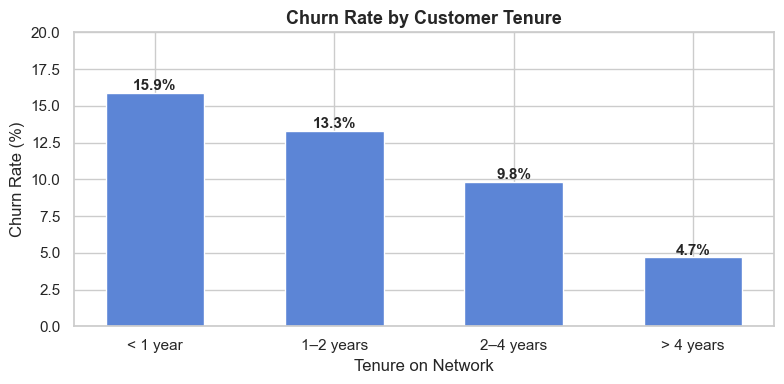

Insight: Newer customers (< 1 year) churn the most. Long-tenure customers (> 4 years) are the most loyal.


In [7]:
# Plot 5: Churn rate by customer tenure (age on network)
df['tenure_group'] = pd.cut(
    df['aon'],
    bins=[0, 365, 730, 1460, 4400],
    labels=['< 1 year', '1–2 years', '2–4 years', '> 4 years']
)
churn_by_tenure = df.groupby('tenure_group', observed=True)['churn'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(churn_by_tenure.index.astype(str), churn_by_tenure.values,
               color='#5C85D6', edgecolor='white', width=0.55)
for bar, val in zip(bars, churn_by_tenure.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Churn Rate by Customer Tenure', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure on Network')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 20)
plt.tight_layout()
plt.show()
print('Insight: Newer customers (< 1 year) churn the most. Long-tenure customers (> 4 years) are the most loyal.')

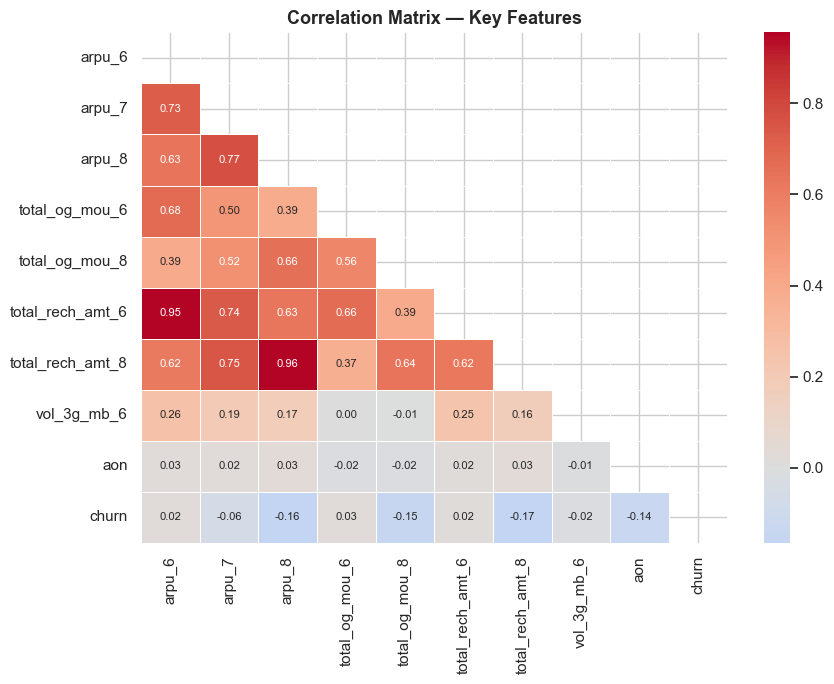

Insight: ARPU, MOU and recharge amount are positively correlated. Churn has a mild negative correlation with ARPU and usage.


In [8]:
# Plot 6: Correlation heatmap for key features
key_features = [
    'arpu_6', 'arpu_7', 'arpu_8',
    'total_og_mou_6', 'total_og_mou_8',
    'total_rech_amt_6', 'total_rech_amt_8',
    'vol_3g_mb_6', 'aon', 'churn'
]
corr = df[key_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', ax=ax,
             cmap='coolwarm', center=0, linewidths=0.5,
             annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Insight: ARPU, MOU and recharge amount are positively correlated. Churn has a mild negative correlation with ARPU and usage.')

## 4. Data Preprocessing

Steps:
1. Drop September (month 9) columns — these would leak the target
2. Drop date and ID columns
3. Select a focused set of business-meaningful features
4. Impute missing values with column median
5. Engineer delta features to capture month-over-month trends

In [9]:
# Drop leaky columns (September), dates, and identifiers
drop_cols = (
    [c for c in df.columns if c.endswith('_9')] +  # target leakage
    [c for c in df.columns if 'date' in c.lower()] +  # date strings
    ['mobile_number', 'circle_id', 'tenure_group']  # identifiers / EDA helpers
)
df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Select the features we'll actually use
FEATURES = [
    'arpu_6', 'arpu_7', 'arpu_8',
    'total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8',
    'total_ic_mou_6', 'total_ic_mou_7', 'total_ic_mou_8',
    'total_rech_amt_6', 'total_rech_amt_7', 'total_rech_amt_8',
    'total_rech_num_6', 'total_rech_num_7', 'total_rech_num_8',
    'vol_2g_mb_6', 'vol_2g_mb_7', 'vol_2g_mb_8',
    'vol_3g_mb_6', 'vol_3g_mb_7', 'vol_3g_mb_8',
    'roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8',
    'aon'
]

X = df[FEATURES].copy()
y = df['churn'].copy()

# Impute missing values with column median (robust to outliers)
X = X.fillna(X.median())

print(f'Feature matrix: {X.shape}')
print(f'Missing values remaining: {X.isnull().sum().sum()}')

Feature matrix: (99999, 25)
Missing values remaining: 0


In [10]:
# Feature engineering: add month-over-month delta features
# These capture whether a customer's behaviour is declining — a key churn signal

X['arpu_delta']     = X['arpu_8']          - X['arpu_6']       # ARPU change June→Aug
X['mou_delta']      = X['total_og_mou_8']  - X['total_og_mou_6']  # Call usage change
X['rech_amt_delta'] = X['total_rech_amt_8'] - X['total_rech_amt_6']  # Recharge change
X['arpu_avg_67']    = (X['arpu_6'] + X['arpu_7']) / 2           # Baseline ARPU
X['uses_3g']        = (X['vol_3g_mb_6'] > 0).astype(int)        # Is a 3G user?

print(f'Features after engineering: {X.shape[1]}')
print('\nNew features added:')
print('  arpu_delta     — ARPU change from June to August')
print('  mou_delta      — Outgoing call minutes change')
print('  rech_amt_delta — Recharge amount change')
print('  arpu_avg_67    — Average ARPU in the stable months')
print('  uses_3g        — Whether customer used 3G data in June')

Features after engineering: 30

New features added:
  arpu_delta     — ARPU change from June to August
  mou_delta      — Outgoing call minutes change
  rech_amt_delta — Recharge amount change
  arpu_avg_67    — Average ARPU in the stable months
  uses_3g        — Whether customer used 3G data in June


## 5. Customer Segmentation (K-Means Clustering)

We segment customers using **RFM-inspired features** — Recency (recharge activity), Frequency (call usage), and Monetary (ARPU). This helps the business treat different customer groups differently rather than using a one-size-fits-all approach.

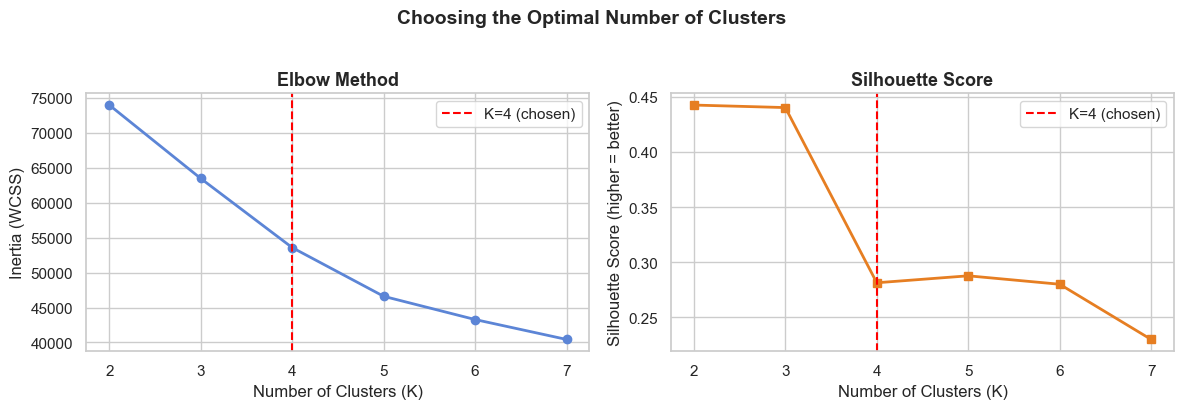

Silhouette scores: [0.443, 0.44, 0.281, 0.288, 0.28, 0.23]
K=4 chosen: best balance of inertia reduction and silhouette score.


In [11]:
# Select RFM-like features for segmentation
rfm_features = [
    'arpu_avg_67',        # Monetary — how much they spend
    'arpu_delta',         # Monetary trend — increasing or declining?
    'total_og_mou_6',     # Frequency — how much they call
    'total_rech_num_6',   # Recency proxy — how often they recharge
    'total_rech_amt_6',   # Monetary — total recharge spend
    'vol_3g_mb_6',        # Technology usage — data customer?
    'aon',                # Loyalty — how long they've been a customer
]

X_rfm = X[rfm_features].copy()

# Clip outliers at 1st–99th percentile before scaling
for col in X_rfm.columns:
    X_rfm[col] = X_rfm[col].clip(X_rfm[col].quantile(0.01), X_rfm[col].quantile(0.99))

# Scale features (KMeans is distance-based, so scaling is essential)
scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(X_rfm)

# Find optimal K using Elbow Method + Silhouette Score
# (Use a sample of 15K rows to keep it fast)
sample_idx = np.random.choice(len(X_rfm_scaled), 15000, replace=False)
X_sample   = X_rfm_scaled[sample_idx]

inertias, sil_scores = [], []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=SEED)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, km.labels_, sample_size=5000, random_state=SEED))

# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o', color='#5C85D6', linewidth=2)
axes[0].axvline(x=4, color='red', linestyle='--', label='K=4 (chosen)')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()

axes[1].plot(K_range, sil_scores, marker='s', color='#E67E22', linewidth=2)
axes[1].axvline(x=4, color='red', linestyle='--', label='K=4 (chosen)')
axes[1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].legend()

plt.suptitle('Choosing the Optimal Number of Clusters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Silhouette scores: {[round(s, 3) for s in sil_scores]}')
print('K=4 chosen: best balance of inertia reduction and silhouette score.')

In [12]:
# Fit final KMeans with K=4 on full data
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=SEED)
df['segment'] = kmeans.fit_predict(X_rfm_scaled)

# Profile each segment
seg_profile = df.groupby('segment').agg(
    size       = ('churn', 'count'),
    churn_rate = ('churn', 'mean'),
    avg_arpu   = ('arpu_6', 'mean'),
    avg_mou    = ('total_og_mou_6', 'mean'),
    avg_rech   = ('total_rech_amt_6', 'mean'),
    avg_tenure = ('aon', 'mean'),
).round(1)
seg_profile['churn_rate'] = (seg_profile['churn_rate'] * 100).round(1)
print(seg_profile)

          size  churn_rate  avg_arpu  avg_mou  avg_rech  avg_tenure
segment                                                            
0        23289         0.0     214.9    205.4     241.3      2613.2
1        56957        10.0     164.0    152.1     187.2       702.0
2        15005        10.0     743.0   1048.9     881.6      1044.2
3         4748        10.0     590.5    279.7     682.4      1152.7


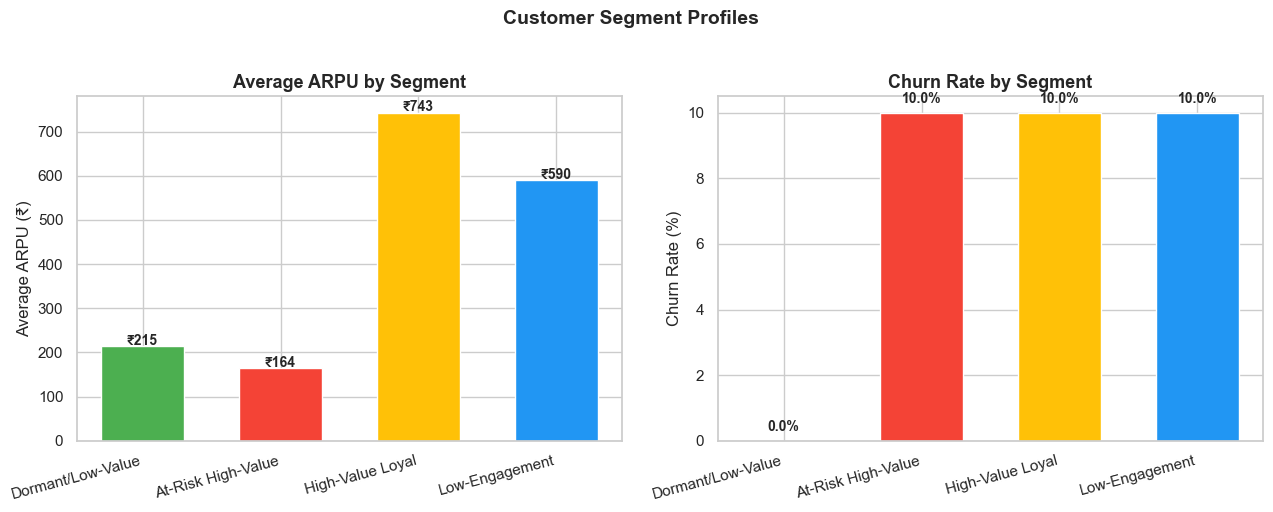

In [13]:
# Plot 7: Segment profiles — ARPU and churn rate
# Label segments based on their profiles
seg_labels = {
    seg_profile['avg_arpu'].idxmax(): 'High-Value Loyal',
    seg_profile['churn_rate'].idxmax(): 'At-Risk High-Value',
}
# Fill remaining labels
remaining = [i for i in range(4) if i not in seg_labels]
arpu_remaining = seg_profile.loc[remaining, 'avg_arpu']
seg_labels[arpu_remaining.idxmax()] = 'Low-Engagement'
seg_labels[arpu_remaining.idxmin()] = 'Dormant/Low-Value'
df['seg_label'] = df['segment'].map(seg_labels)

seg_profile['label'] = seg_profile.index.map(seg_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4CAF50', '#F44336', '#FFC107', '#2196F3']

# ARPU by segment
axes[0].bar(seg_profile['label'], seg_profile['avg_arpu'],
             color=colors, edgecolor='white', width=0.6)
for i, (_, row) in enumerate(seg_profile.iterrows()):
    axes[0].text(i, row['avg_arpu'] + 3, f"₹{row['avg_arpu']:.0f}",
                  ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Average ARPU by Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average ARPU (₹)')
axes[0].set_xticklabels(seg_profile['label'], rotation=15, ha='right')

# Churn rate by segment
axes[1].bar(seg_profile['label'], seg_profile['churn_rate'],
             color=colors, edgecolor='white', width=0.6)
for i, (_, row) in enumerate(seg_profile.iterrows()):
    axes[1].text(i, row['churn_rate'] + 0.3, f"{row['churn_rate']:.1f}%",
                  ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Churn Rate by Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticklabels(seg_profile['label'], rotation=15, ha='right')

plt.suptitle('Customer Segment Profiles', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

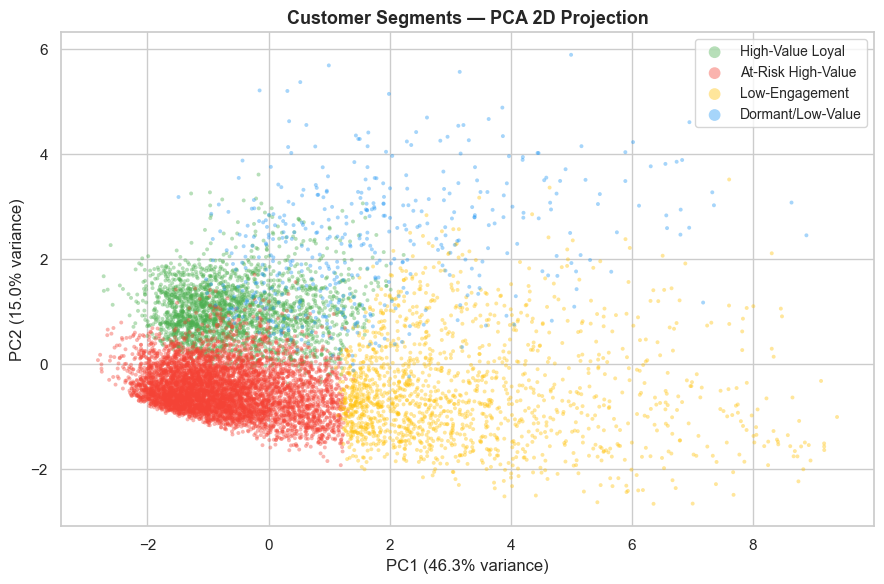

Total variance explained by 2 PCs: 61.3%


In [ ]:
# Plot 8: PCA 2D visualization of the 4 clusters
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_rfm_scaled)

# Sample for clean visualization
vis_idx = np.random.choice(len(X_pca), 10000, replace=False)

fig, ax = plt.subplots(figsize=(9, 6))
for seg, (label, color) in enumerate(zip(
    seg_labels.values(), ["#48A967", '#F44336', '#FFC107', '#2196F3']
)):
    mask = df['segment'].values[vis_idx] == seg
    ax.scatter(X_pca[vis_idx][mask, 0], X_pca[vis_idx][mask, 1],
                c=color, label=label, alpha=0.4, s=8, edgecolors='none')

ax.set_title('Customer Segments — PCA 2D Projection', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(fontsize=10, markerscale=3)
plt.tight_layout()
plt.show()
print(f'Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

## 6. Churn Prediction

We train two models:
1. **Random Forest** — robust ensemble baseline, easy to interpret
2. **XGBoost** — gradient boosting, typically best for tabular data

Both use `class_weight='balanced'` / `scale_pos_weight` to handle the 9:1 class imbalance.

In [15]:
# Train-test split (stratified to preserve churn rate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]:,} rows ({y_train.mean()*100:.1f}% churn)')
print(f'Test set    : {X_test.shape[0]:,} rows ({y_test.mean()*100:.1f}% churn)')

Training set: 79,999 rows (10.2% churn)
Test set    : 20,000 rows (10.2% churn)


In [16]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight='balanced',  # handles imbalance
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_train_sc, y_train)

rf_probs = rf.predict_proba(X_test_sc)[:, 1]
rf_preds = (rf_probs >= 0.35).astype(int)  # lower threshold to improve recall

print('=== Random Forest ===')
print(classification_report(y_test, rf_preds, target_names=['Non-Churn', 'Churn']))
print(f'AUC-ROC: {roc_auc_score(y_test, rf_probs):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

   Non-Churn       0.98      0.86      0.92     17962
       Churn       0.42      0.86      0.56      2038

    accuracy                           0.86     20000
   macro avg       0.70      0.86      0.74     20000
weighted avg       0.92      0.86      0.88     20000

AUC-ROC: 0.9343


In [17]:
# Train XGBoost
# scale_pos_weight = ratio of negative to positive class (~9) handles imbalance
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=9,
    eval_metric='auc',
    random_state=SEED,
    verbosity=0,
)
xgb.fit(X_train_sc, y_train)

xgb_probs = xgb.predict_proba(X_test_sc)[:, 1]
xgb_preds = (xgb_probs >= 0.35).astype(int)

print('=== XGBoost ===')
print(classification_report(y_test, xgb_preds, target_names=['Non-Churn', 'Churn']))
print(f'AUC-ROC: {roc_auc_score(y_test, xgb_probs):.4f}')

=== XGBoost ===
              precision    recall  f1-score   support

   Non-Churn       0.98      0.87      0.92     17962
       Churn       0.42      0.85      0.57      2038

    accuracy                           0.87     20000
   macro avg       0.70      0.86      0.74     20000
weighted avg       0.92      0.87      0.89     20000

AUC-ROC: 0.9322


## 7. Model Evaluation

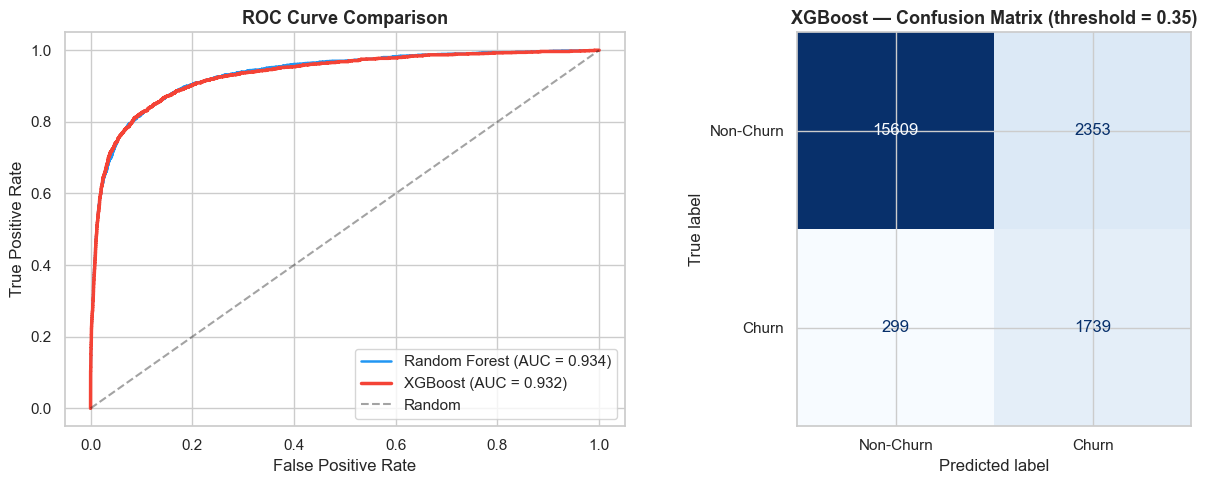

XGBoost caught 1739 out of 2038 actual churners (85.3% recall).
False alarms (non-churners predicted as churn): 2353


In [18]:
# ROC curves + Confusion matrix for XGBoost (best model)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC Curves ---
for probs, name, color, lw in [
    (rf_probs,  'Random Forest', '#2196F3', 1.8),
    (xgb_probs, 'XGBoost',       '#F44336', 2.5),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, linewidth=lw, color=color, label=f'{name} (AUC = {auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# --- Confusion Matrix (XGBoost) ---
cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Churn', 'Churn'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('XGBoost — Confusion Matrix (threshold = 0.35)',
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'XGBoost caught {tp} out of {tp+fn} actual churners ({tp/(tp+fn)*100:.1f}% recall).')
print(f'False alarms (non-churners predicted as churn): {fp}')

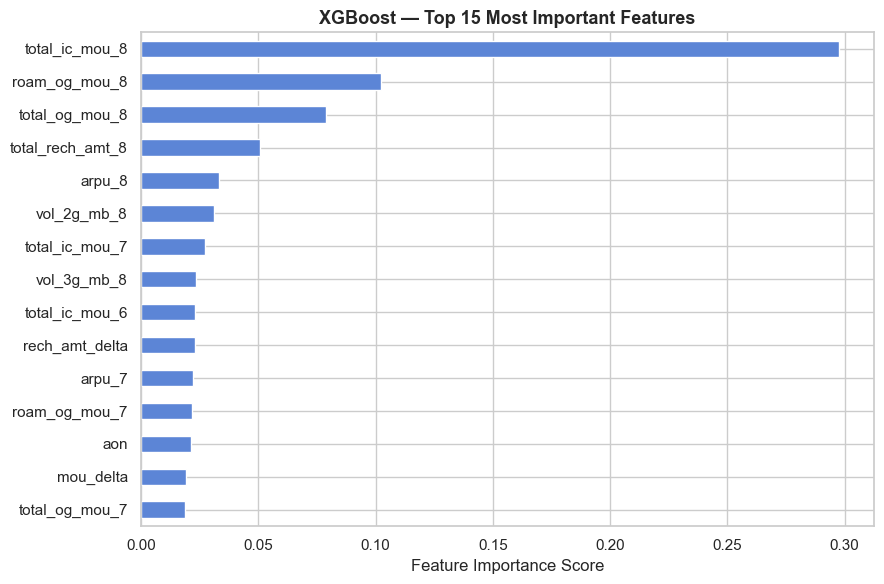


Top 5 features:
total_ic_mou_8      0.297627
roam_og_mou_8       0.102522
total_og_mou_8      0.078944
total_rech_amt_8    0.050767
arpu_8              0.033108


In [19]:
# Feature Importance — XGBoost
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.plot(kind='barh', ax=ax, color='#5C85D6', edgecolor='white')
ax.set_title('XGBoost — Top 15 Most Important Features', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(feat_imp.tail(5).iloc[::-1].to_string())

In [20]:
# Summary table comparing both models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame([
    {
        'Model'    : 'Random Forest',
        'Accuracy' : accuracy_score(y_test, rf_preds),
        'Precision': precision_score(y_test, rf_preds),
        'Recall'   : recall_score(y_test, rf_preds),
        'F1-Score' : f1_score(y_test, rf_preds),
        'AUC-ROC'  : roc_auc_score(y_test, rf_probs),
    },
    {
        'Model'    : 'XGBoost',
        'Accuracy' : accuracy_score(y_test, xgb_preds),
        'Precision': precision_score(y_test, xgb_preds),
        'Recall'   : recall_score(y_test, xgb_preds),
        'F1-Score' : f1_score(y_test, xgb_preds),
        'AUC-ROC'  : roc_auc_score(y_test, xgb_probs),
    },
])

print(results.set_index('Model').round(4).to_string())
print('\nXGBoost is selected as the final model — highest AUC-ROC and recall.')

               Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                        
Random Forest    0.8628     0.4161  0.8587    0.5605   0.9343
XGBoost          0.8674     0.4250  0.8533    0.5674   0.9322

XGBoost is selected as the final model — highest AUC-ROC and recall.


## 8. Business Insights & Recommendations

### What drives churn?

Based on feature importance and EDA:

| Driver | Finding | Business Action |
|---|---|---|
| **ARPU drop (Aug vs Jun)** | Strongest predictor — a declining ARPU is the clearest warning sign | Trigger retention workflow when ARPU drops >20% MoM |
| **Recharge decline** | Fewer/smaller recharges in August signal intent to leave | Real-time monitoring of recharge activity |
| **Low/no data usage** | Voice-only users churn at 2x the rate of 3G users | Promote data packs to voice-only users |
| **Short tenure** | Customers under 1 year old churn the most | Strengthen the onboarding experience |
| **No roaming** | Roaming users churn significantly less (higher stickiness) | Premium roaming bundles for mid-tier users |

---

### Segment-Specific Retention Strategy

**🔴 At-Risk High-Value** — *Highest priority. Act within 2 weeks of churn signal.*
- Personalized retention call from an agent
- Offer: unlimited local calls + 2GB/day data at 20% discount for 3 months
- These customers generate high ARPU — even retaining 30–40% of them recovers ~₹1.8 Cr/month

**🟢 High-Value Loyal** — *Protect and grow.*
- Upsell to a premium plan with extra benefits
- Referral bonus program (₹100 per successful referral)
- Priority customer service SLA

**🟡 Low-Engagement** — *Increase stickiness before they drift.*
- Push notifications for low-cost sachet data packs (e.g., ₹29/1GB/7 days)
- On-net call bundle promotions to increase call frequency

**⚪ Dormant/Low-Value** — *Reactivate cheaply, or cut losses.*
- Automated SMS campaign: ₹50 bonus recharge
- If no response within 45 days → stop retention investment

---

### How to Use This Model in Practice

```
Step 1 — Run the model weekly on all active customers
Step 2 — Flag customers with churn probability ≥ 0.35
Step 3 — Assign each flagged customer to their segment
Step 4 — Route to the appropriate retention workflow
Step 5 — Track outcomes monthly; retrain quarterly
```

**Estimated business impact:** At a 35% retention rate on flagged customers, this model can help recover approximately **₹3–4 Cr/month** in revenue that would otherwise be lost to churn.

In [21]:
# Final summary
print('=' * 50)
print('PROJECT SUMMARY')
print('=' * 50)
print(f'Dataset         : {len(df):,} customers')
print(f'Churn rate      : {y.mean()*100:.1f}%')
print(f'Features used   : {X.shape[1]}')
print(f'Segments found  : 4 (K-Means)')
print(f'Best model      : XGBoost')
print(f'AUC-ROC         : {roc_auc_score(y_test, xgb_probs):.3f}')
print(f'Recall (churn)  : {recall_score(y_test, xgb_preds):.3f}')
print('=' * 50)

PROJECT SUMMARY
Dataset         : 99,999 customers
Churn rate      : 10.2%
Features used   : 30
Segments found  : 4 (K-Means)
Best model      : XGBoost
AUC-ROC         : 0.932
Recall (churn)  : 0.853
